<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/gas_cost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rows in county_average: 3222
Successfully matched rows in merged: 3005


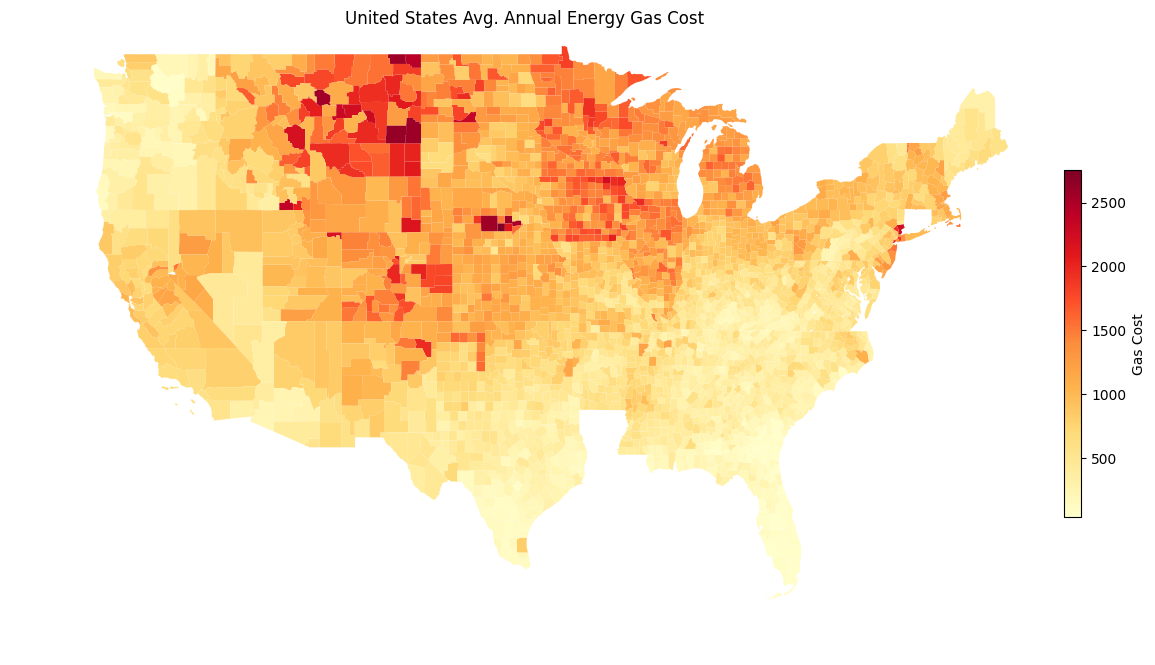

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
!pip install geodatasets




df = pd.read_csv(
    '/content/LEAD Tool Data Census Tracts (Jun 9, 2026 11_58am).csv', skiprows=7)
df

target = 'Avg. Annual Energy Cost ($) (Gas)'
df['target'] = pd.to_numeric(df[target], errors='coerce')
county_average = df.groupby(['State', 'County'])['target'].mean().reset_index()

#county map for census
county_map_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip"
geo = gpd.read_file(county_map_url)

#to match shapes
geo['County_state'] = geo['NAME'] + ' County'

#merged
merged = geo.merge(county_average, left_on=['STATE_NAME', 'County_state'], right_on=['State', 'County'], how='left')
merged

print("Rows in county_average:", len(county_average))
print("Successfully matched rows in merged:", merged['target'].notna().sum())
#plot
fig, ax = plt.subplots(figsize=(16,9))
merged.plot(column= 'target', legend=True, ax=ax, cmap='YlOrRd', legend_kwds={'label': "Gas Cost", 'orientation': "vertical", 'shrink': 0.5, 'pad' :0.02})
ax.set_xlim(-130,-65)
ax.set_ylim(22,50)
ax.set_title('United States Avg. Annual Energy Gas Cost')
ax.axis('off')
plt.show()
